Inverse: (np.float64(5.137973858458539), np.float64(0.03649150590697707))
Wiener: (np.float64(18.453978756795326), np.float64(0.23716103905892133))
CLS: (np.float64(19.46994691120107), np.float64(0.48822295509463803))
Richardson-Lucy: (np.float64(27.59984120864833), np.float64(0.8001328547324539))
Median: (np.float64(28.66061238389157), np.float64(0.8773106844162333))


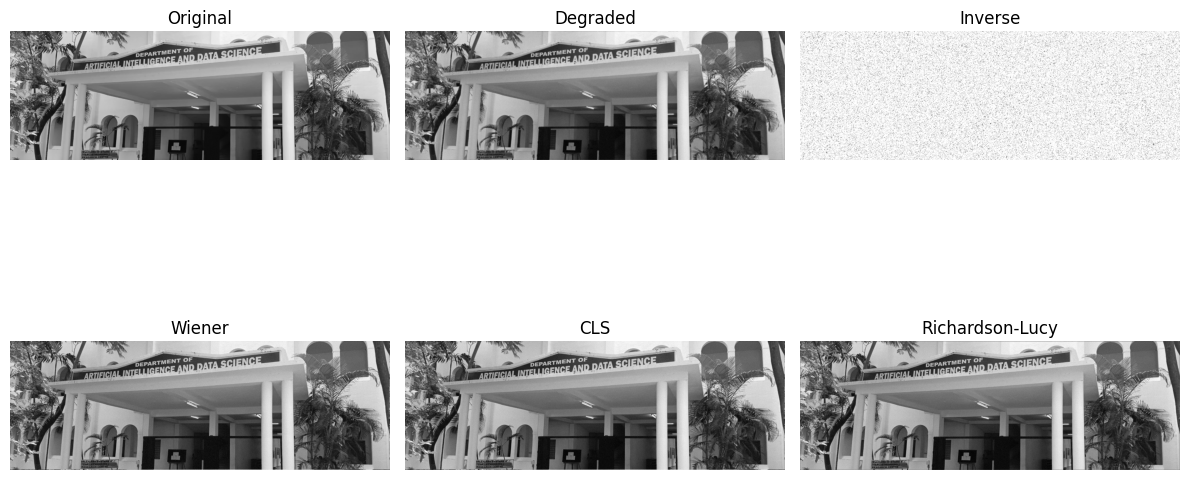

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from scipy.signal import convolve2d

image = cv2.imread("test2.jpg", 0)

def gaussian_kernel(size, sigma):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

psf = gaussian_kernel(5, 1)

blurred = convolve2d(image, psf, mode='same', boundary='wrap')

noise = np.random.normal(0, 5, image.shape)
degraded = blurred + noise
degraded = np.clip(degraded, 0, 255).astype(np.uint8)

def inverse_filter(img, psf):
    img_f = np.fft.fft2(img)
    psf_f = np.fft.fft2(psf, s=img.shape)
    result = np.fft.ifft2(img_f / (psf_f + 1e-5))
    return np.abs(result)

def wiener_filter(img, psf, k=0.01):
    img_f = np.fft.fft2(img)
    psf_f = np.fft.fft2(psf, s=img.shape)
    psf_conj = np.conj(psf_f)
    result = (psf_conj / (np.abs(psf_f)**2 + k)) * img_f
    return np.abs(np.fft.ifft2(result))

def constrained_ls(img, psf, gamma=0.01):
    img_f = np.fft.fft2(img)
    psf_f = np.fft.fft2(psf, s=img.shape)
    lap = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
    lap_f = np.fft.fft2(lap, s=img.shape)
    result = (np.conj(psf_f) / (np.abs(psf_f)**2 + gamma * np.abs(lap_f)**2)) * img_f
    return np.abs(np.fft.ifft2(result))

def richardson_lucy(img, psf, iterations=10):
    img = img.astype(np.float64)
    estimate = np.full(img.shape, 0.5)
    psf_mirror = psf[::-1, ::-1]
    for _ in range(iterations):
        conv = convolve2d(estimate, psf, mode='same')
        relative_blur = img / (conv + 1e-5)
        estimate *= convolve2d(relative_blur, psf_mirror, mode='same')
    return estimate

inv = inverse_filter(degraded, psf)
wiener = wiener_filter(degraded, psf)
cls = constrained_ls(degraded, psf)
rl = richardson_lucy(degraded, psf)

median = cv2.medianBlur(degraded, 3)

inv = np.uint8(np.clip(inv, 0, 255))
wiener = np.uint8(np.clip(wiener, 0, 255))
cls = np.uint8(np.clip(cls, 0, 255))
rl = np.uint8(np.clip(rl, 0, 255))

def metrics(orig, restored):
    return psnr(orig, restored), ssim(orig, restored)

print("Inverse:", metrics(image, inv))
print("Wiener:", metrics(image, wiener))
print("CLS:", metrics(image, cls))
print("Richardson-Lucy:", metrics(image, rl))
print("Median:", metrics(image, median))

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Degraded")
plt.imshow(degraded, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Inverse")
plt.imshow(inv, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Wiener")
plt.imshow(wiener, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("CLS")
plt.imshow(cls, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Richardson-Lucy")
plt.imshow(rl, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()